<a href="https://colab.research.google.com/github/kp-tech-19/Analog-and-Digital-Communication-Lab-MATLAB/blob/main/ML_FETAL_RISK_PERDICTION_CTG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **`Fetal Health Risk Prediction using Cardiotocography`**

**Import libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

**Load dataset**

In [ ]:
df = pd.read_csv("fetal_health.csv")
print(df.shape)
print(df.info())

(2126, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_va

**Count Fetal Health Classes**

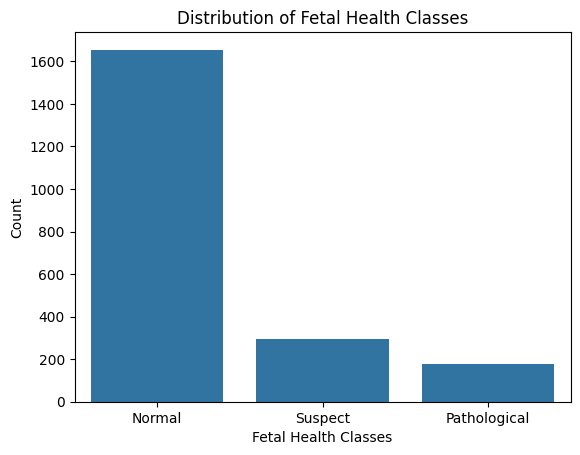

Total number of samples: 2126

Samples in each class:
Normal: 1655
Suspect: 295
Pathological: 176


In [ ]:
sns.countplot(x='fetal_health', data=df)
plt.title("Distribution of Fetal Health Classes")
plt.xlabel("Fetal Health Classes")
plt.ylabel("Count")
plt.xticks(ticks=[0,1,2], labels=['Normal','Suspect','Pathological'])
plt.show()

total_samples = df.shape[0]
print("Total number of samples:", total_samples)

class_counts = df['fetal_health'].value_counts().sort_index()
print("\nSamples in each class:")
print("Normal:", class_counts[1])
print("Suspect:", class_counts[2])
print("Pathological:", class_counts[3])

**Data Cleaning**

In [ ]:
print(df.isnull().sum())                   #Check for missing values
df = df.dropna()                           #drop missing values
df = df.drop_duplicates()                  #Check for duplicate rows

baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mode                          

**Exploratory Data Analysis (EDA)**

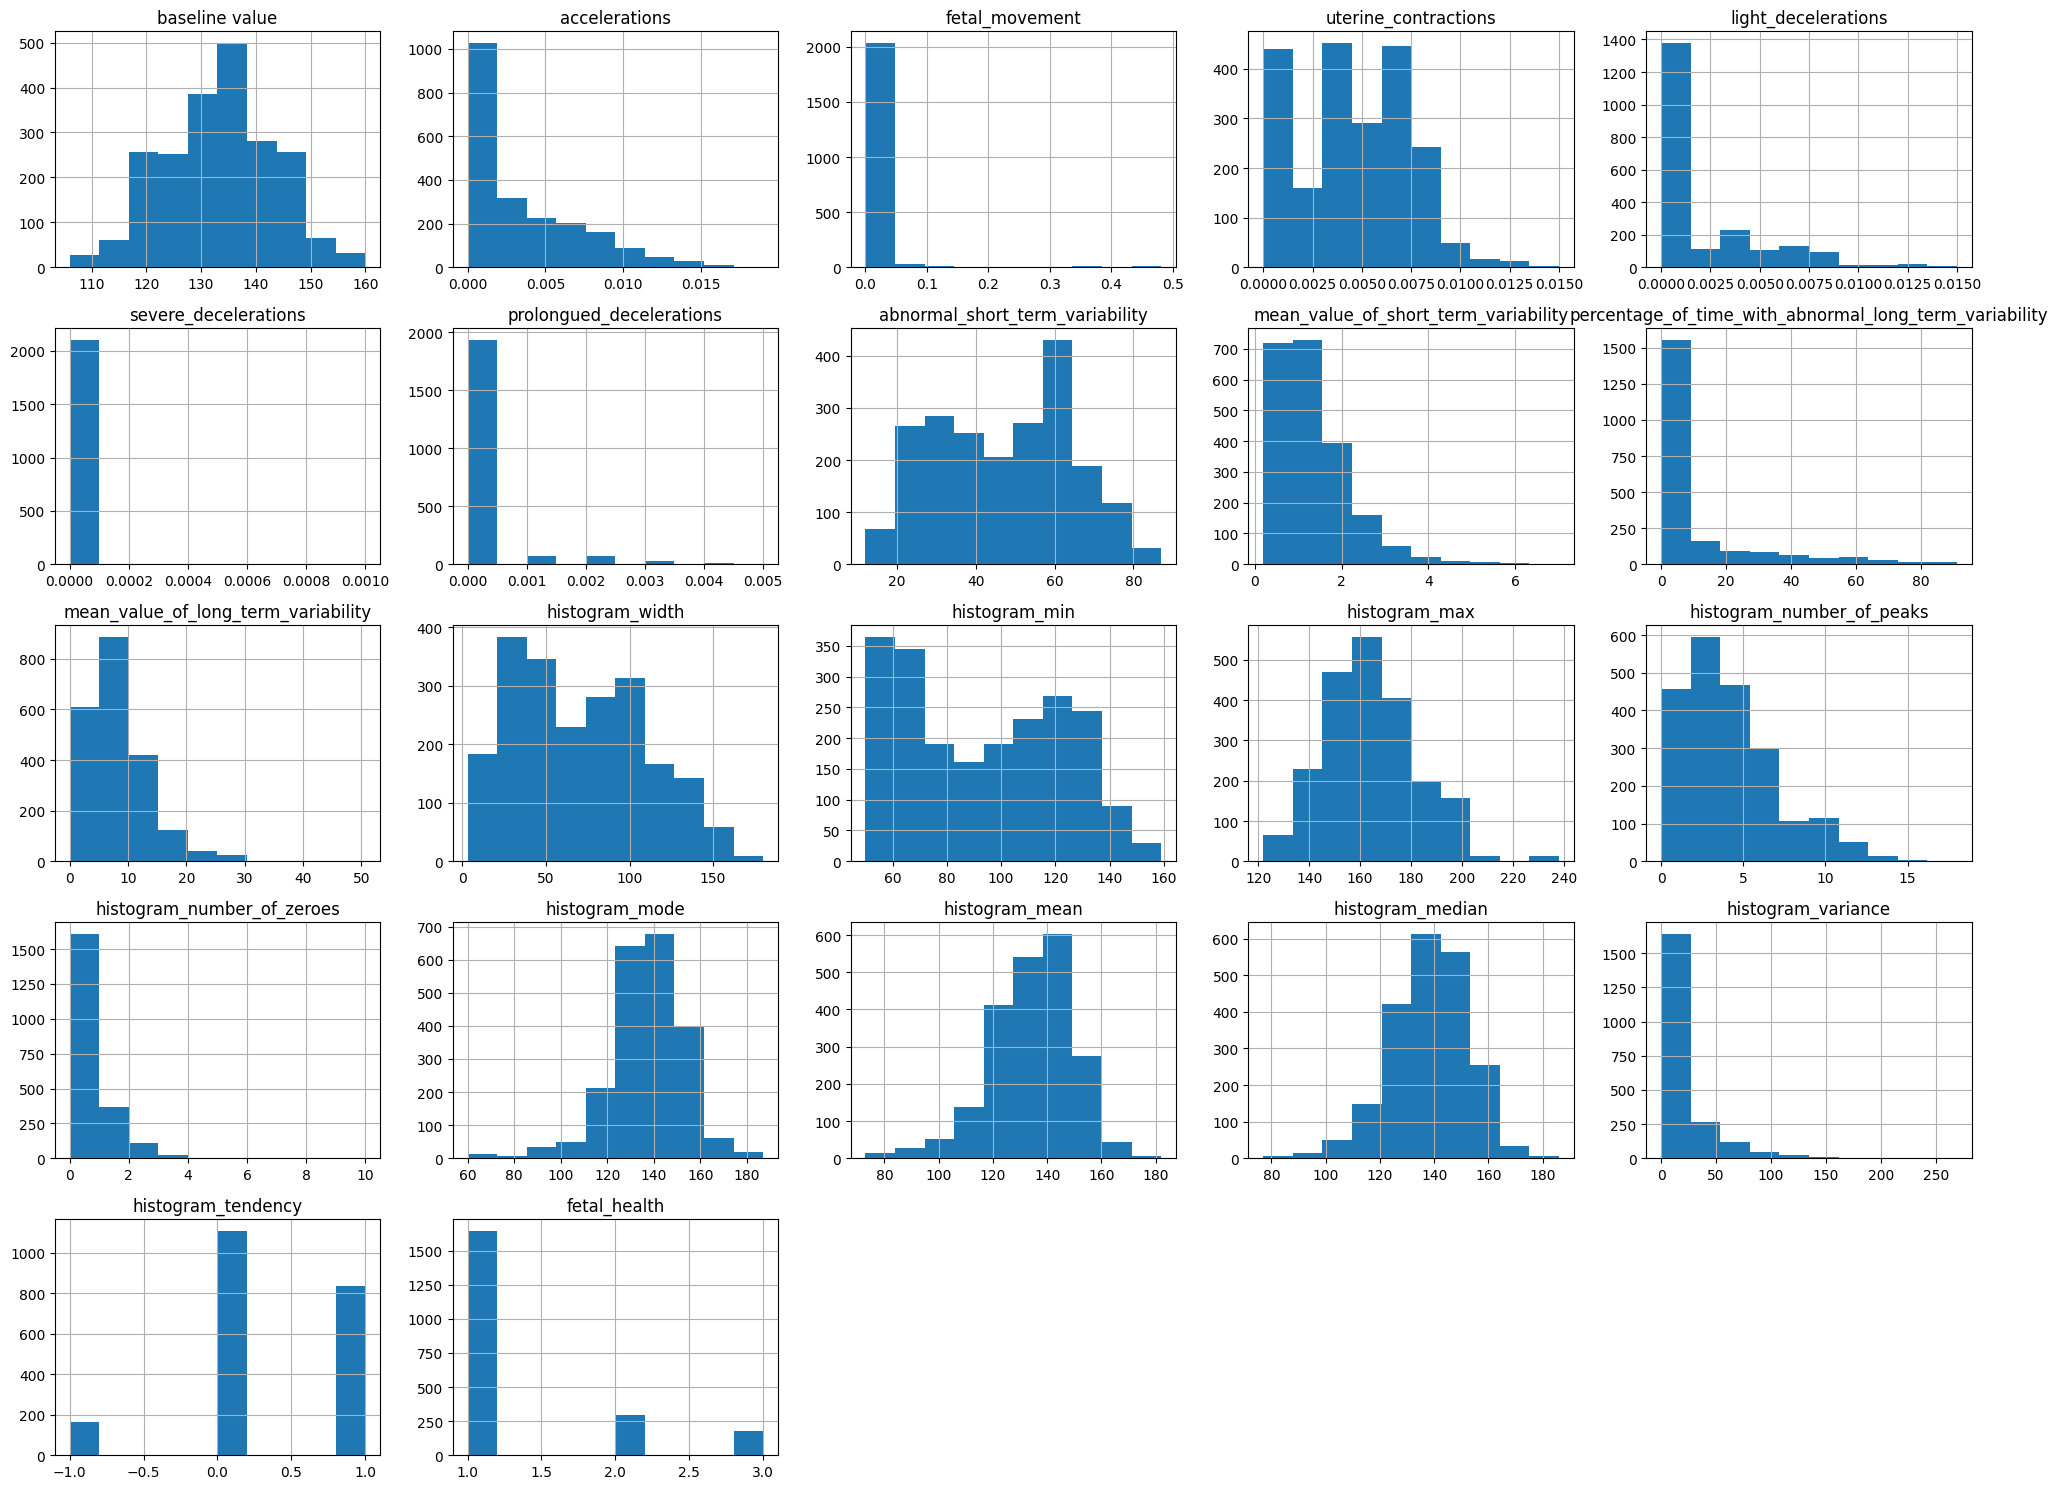

In [ ]:
#Plot histograms for features
df.hist(figsize=(20,15))
plt.tight_layout()
plt.show()

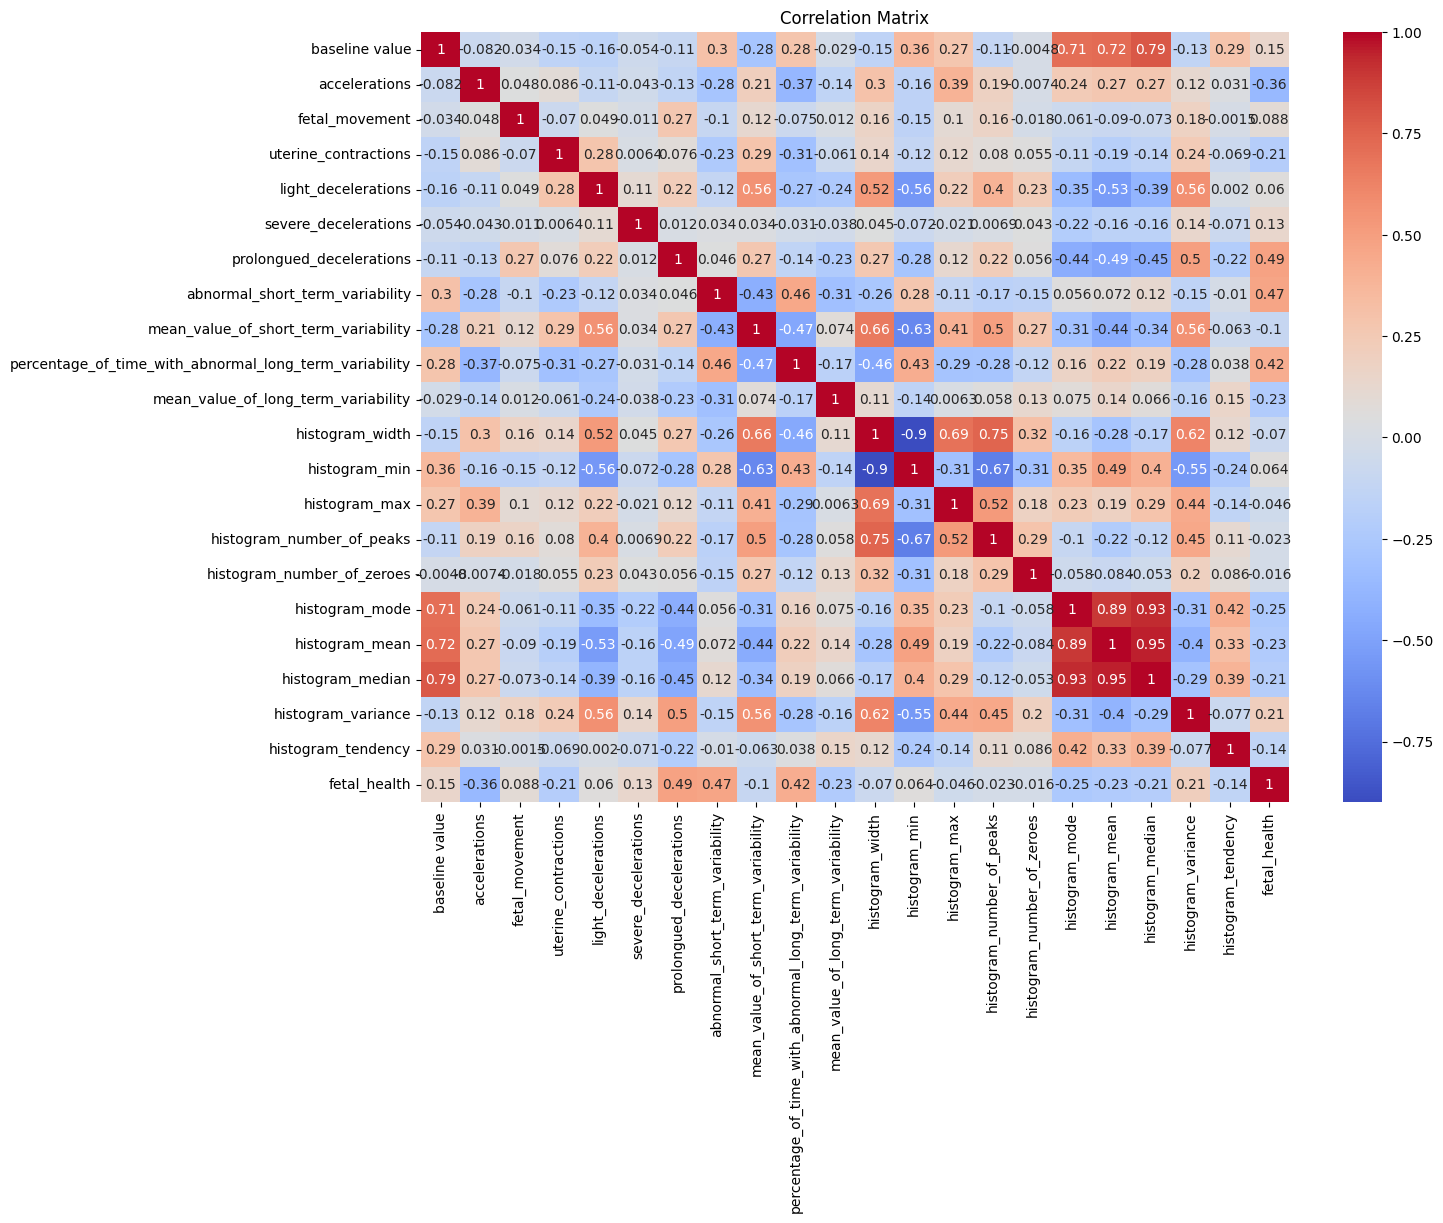

In [ ]:
#Correlation matrix
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

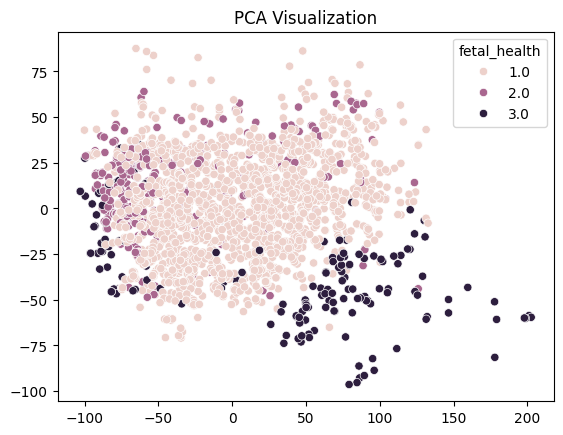

In [ ]:
#pca
X = df.drop("fetal_health", axis=1)
y = df["fetal_health"]
pca = PCA(n_components=2)
X_selected = pca.fit_transform(X)
X_pca = pca.fit_transform(X_selected)

plt.figure()
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y)
plt.title("PCA Visualization")
plt.show()

**Feature Selection - Using Random forest and correlation with target**

fetal_health                                              1.000000
prolongued_decelerations                                  0.486752
abnormal_short_term_variability                           0.469671
percentage_of_time_with_abnormal_long_term_variability    0.421634
histogram_variance                                        0.208171
baseline value                                            0.146077
severe_decelerations                                      0.132408
fetal_movement                                            0.088057
histogram_min                                             0.063529
light_decelerations                                       0.059651
histogram_number_of_zeroes                               -0.016376
histogram_number_of_peaks                                -0.022856
histogram_max                                            -0.046480
histogram_width                                          -0.069529
mean_value_of_short_term_variability                     -0.10

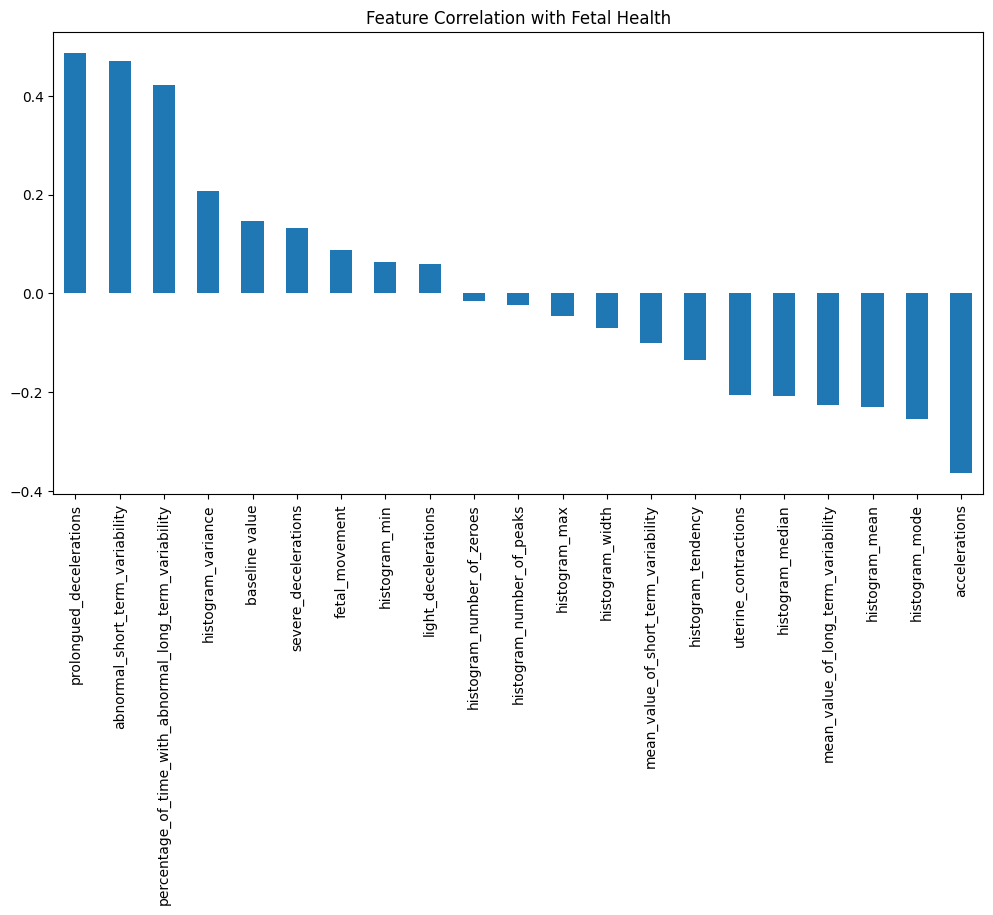

In [ ]:
#Check feature correlation with target
corr_target = df.corr()['fetal_health'].sort_values(ascending=False)
print(corr_target)
corr_target.drop('fetal_health').plot(kind='bar', figsize=(12,6))
plt.title("Feature Correlation with Fetal Health")
plt.show()

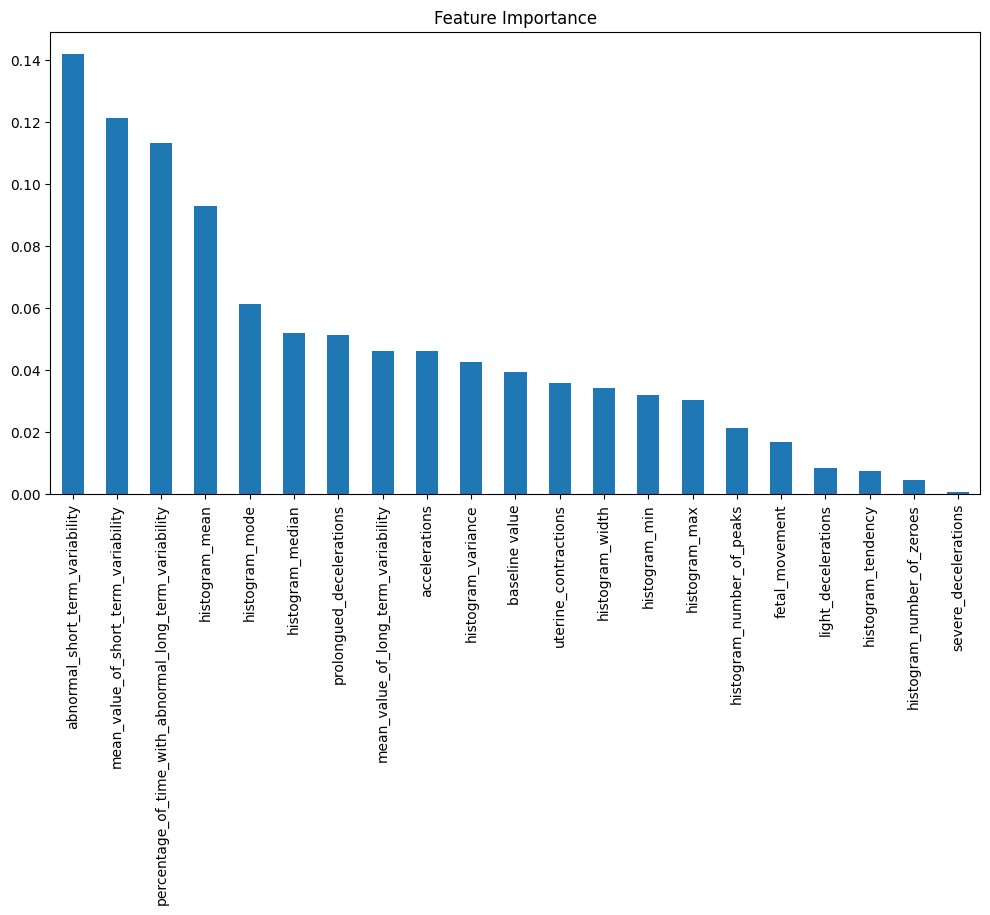

In [ ]:
#Using Random Forest to get feature importance
from sklearn.ensemble import RandomForestClassifier

X = df.drop("fetal_health", axis=1)
y = df["fetal_health"]

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind='bar', figsize=(12,6))
plt.title("Feature Importance")
plt.show()

In [ ]:
#Select top features for your model
top_features = importance.sort_values(ascending=False).head(12).index
X_selected = X[top_features]
print("Top Selected Features:")
print(top_features)

Top Selected Features:
Index(['abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'histogram_mean', 'histogram_mode', 'histogram_median',
       'prolongued_decelerations', 'mean_value_of_long_term_variability',
       'accelerations', 'histogram_variance', 'baseline value',
       'uterine_contractions'],
      dtype='object')


**Split and Scale Data**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Logistic Regression**


default solver - lbfgs solver converged before 50 iterations so didn't go for 100 or more iterations


Logistic Regression Report:

              precision    recall  f1-score   support

         1.0       0.92      0.96      0.94       330
         2.0       0.62      0.52      0.57        58
         3.0       0.86      0.71      0.78        35

    accuracy                           0.88       423
   macro avg       0.80      0.73      0.76       423
weighted avg       0.87      0.88      0.87       423

Accuracy: 0.8794326241134752


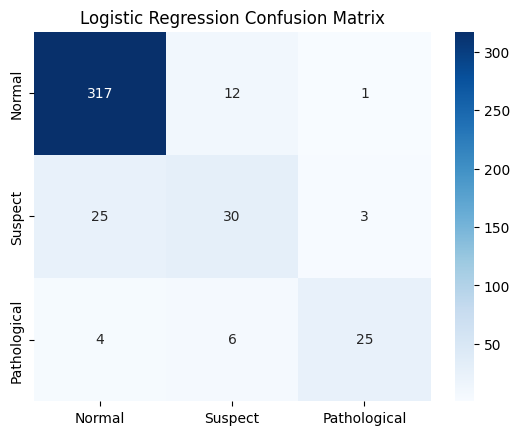

In [ ]:
# Train model
log_model = LogisticRegression(max_iter=50 ,random_state=42)
log_model.fit(X_train_scaled, y_train)

# Predict
y_pred_log = log_model.predict(X_test_scaled)

# Evaluation
print("\nLogistic Regression Report:\n")
print(classification_report(y_test, y_pred_log))

print("Accuracy:", accuracy_score(y_test, y_pred_log))

# Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Suspect','Pathological'],
            yticklabels=['Normal','Suspect','Pathological'])
plt.title("Logistic Regression Confusion Matrix")
plt.show()

**SVM**

rbf - radial basis function - suitable for non linear patterns

gamma and c are the hyperparameters

gamma='scale' - auto adjusts c - error penalty - maximum accuracy obtained for value=40


SVM Report:

              precision    recall  f1-score   support

         1.0       0.96      0.98      0.97       330
         2.0       0.84      0.72      0.78        58
         3.0       0.94      0.94      0.94        35

    accuracy                           0.94       423
   macro avg       0.91      0.88      0.90       423
weighted avg       0.94      0.94      0.94       423

Accuracy: 0.9432624113475178


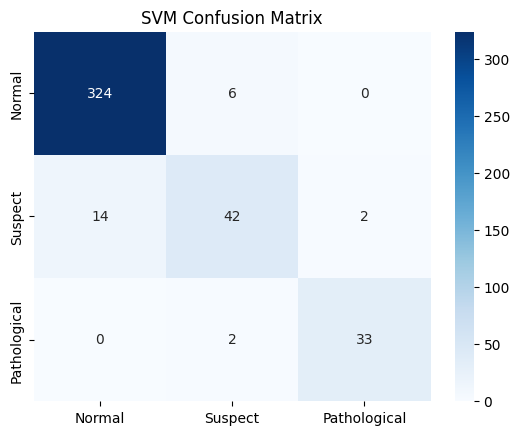

In [ ]:
# Train model
svm_model = SVC(kernel='rbf', C=40, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluation
print("\nSVM Report:\n")
print(classification_report(y_test, y_pred_svm))

print("Accuracy:", accuracy_score(y_test, y_pred_svm))

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Suspect','Pathological'],
            yticklabels=['Normal','Suspect','Pathological'])
plt.title("SVM Confusion Matrix")
plt.show()

**Decision Trees**

maximum accuracy obtained when the depth is 7, after 7 the accuracy is decreasing


Decision Tree Report:

              precision    recall  f1-score   support

         1.0       0.93      0.99      0.96       330
         2.0       0.90      0.66      0.76        58
         3.0       1.00      0.91      0.96        35

    accuracy                           0.94       423
   macro avg       0.95      0.85      0.89       423
weighted avg       0.94      0.94      0.93       423

Accuracy: 0.9361702127659575


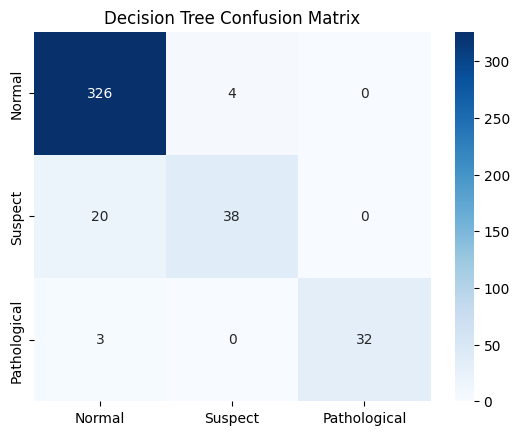

In [ ]:
# Train model
dt_model = DecisionTreeClassifier(max_depth=7, random_state=42)
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)

# Evaluation
print("\nDecision Tree Report:\n")
print(classification_report(y_test, y_pred_dt))

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Suspect','Pathological'],
            yticklabels=['Normal','Suspect','Pathological'])
plt.title("Decision Tree Confusion Matrix")
plt.show()

**Training Model - XGboost**

XGBoost is an algorithm that builds many small decision trees step-by-step, where each new tree learns from the mistakes of the previous trees to improve prediction accuracy.

**Parameter**

1.learning_rate --> 0.01 – 0.3

  * if increase 0.1 → 0.3 Training and Model learns faster, overfitting

 * if decrease 0.1 → 0.01 Training slower, stable learning

2.n_estimators --> 100 – 500
  
  * if increase 200 → 500 Training time increases, overfitting, Can capture complex patterns
  
  * if decrease 200 → 50 Training faster, Model may underfit

3.max_depth --> 3 – 10

  * if increase 4 → 8 Trees become more complex, overfitting, Can capture complex patterns
  
  * if decrease 4 → 2 Simpler model, May miss complex patterns

4.random_state -->any value(1,42,100)
  It is only randomness


Classification Report:

              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98       330
         1.0       1.00      0.78      0.87        58
         2.0       1.00      0.97      0.99        35

    accuracy                           0.97       423
   macro avg       0.99      0.92      0.95       423
weighted avg       0.97      0.97      0.97       423



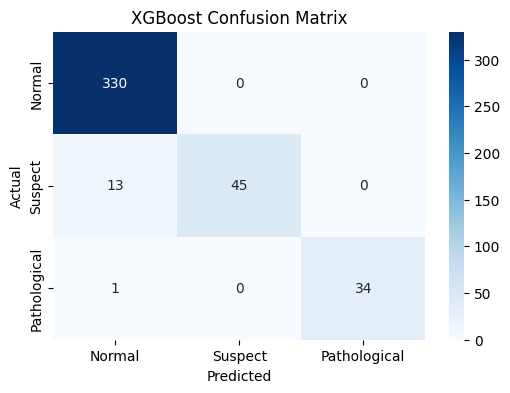

In [ ]:
# XGBoost requires labels starting from 0
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

xgb = XGBClassifier(
    n_estimators=370,
    learning_rate=0.1,
    max_depth=7,
    random_state=42,
    num_class=3,
)

# Train model
xgb.fit(X_train_scaled, y_train_xgb)

# Predict
y_pred = xgb.predict(X_test_scaled)
print("\nClassification Report:\n")
print(classification_report(y_test_xgb, y_pred))


# Confusion Matrix
cm = confusion_matrix(y_test_xgb, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Suspect','Pathological'],
            yticklabels=['Normal','Suspect','Pathological'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

**Test Custom Input Cases**

In [ ]:
selected_features = list(top_features)

test_cases = {
    "Case 1": [10, 10, 1.5, 140, 140, 8, 0, 0.004, 120, 135, 2, 30],
    "Case 2": [71,0.5,47,135,127,123,0,2.4,0,75,125,0],
    "Case 3": [85,0.3,4,137,122,121,123,0,10,1,3,0]
}

for case, values in test_cases.items():
    new_df = pd.DataFrame([values], columns=selected_features)
    new_df = new_df[selected_features]
    new_scaled = scaler.transform(new_df)
    pred = xgb.predict(new_scaled)[0]
    status = ["NORMAL", "SUSPECT", "PATHOLOGICAL"][pred]
    print(f"{case} → Predicted Fetal Health: {status}")

Case 1 → Predicted Fetal Health: NORMAL
Case 2 → Predicted Fetal Health: SUSPECT
Case 3 → Predicted Fetal Health: PATHOLOGICAL


**Model accuracies**

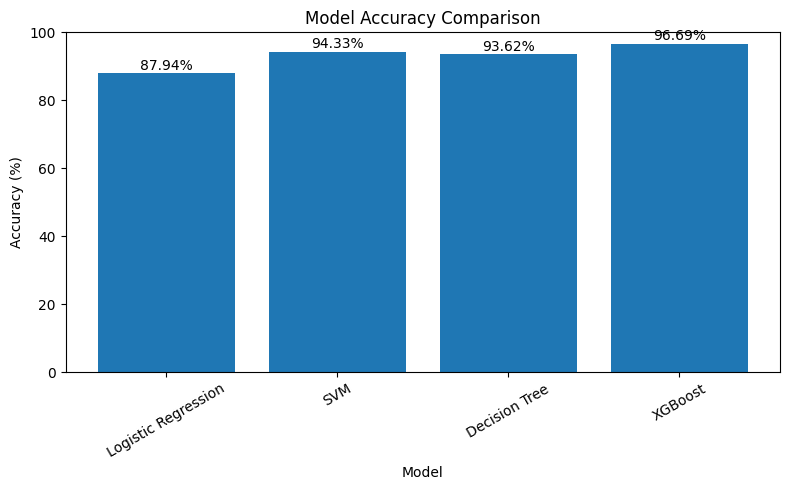

In [ ]:
results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Decision Tree", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test_xgb, y_pred)
    ]
})

# convert to percentage
results_df["Accuracy (%)"] = results_df["Accuracy"] * 100

plt.figure(figsize=(8,5))
bars = plt.bar(results_df["Model"], results_df["Accuracy (%)"])

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30)
plt.ylim(0, 100)

# Add percentage labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.2f}%",
        ha='center'
    )

plt.tight_layout()
plt.show()

**Model downloaded into pickle**

In [ ]:
import joblib

joblib.dump(xgb, "fetal_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(top_features, "features.pkl")

print("Model Saved Successfully")

Model Saved Successfully
